# SECTION 1: IMPORTS AND SETUP

In [1]:
pip install numpy pandas matplotlib nltk scikit-learn scipy

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 630.5 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/9.8 MB 693.3 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.8 MB 779.0 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.8 MB 851.4 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.8 MB 902.4 kB/s eta 0:00:10
   ------- -------------------------------- 1.8/9.8 MB 943.2 kB/s eta 0:00:09
   -------- ------------------------------- 2.1/9.8 MB 971.6 kB/s eta 0:00:08
   --------- ---------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import re
import string
import nltk

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete.")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DEEL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DEEL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DEEL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DEEL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DEEL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\DEEL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_ta

Setup complete.


[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


# Section 2: Dataset Loading

In [3]:
from sklearn.datasets import fetch_20newsgroups

# using 6 categories ==> WSD is computationally expensive.
#   - enough diversity for interesting clustering
#   - Small enough for WSD/lexical chains to run in reasonable time
CATEGORIES = [
    'rec.sport.hockey',
    'sci.space',
    'talk.politics.guns',
    'comp.graphics',
    'rec.autos',
    'sci.med',
]

# Number of clusters = number of categories we chose
# k-Means will find exactly this many clusters
NUM_CLUSTERS = len(CATEGORIES)   # = 6

# subset='all'  → use both train and test splits combined
# remove=...    → strip headers, footers, and quoted replies
print("Loading 20 Newsgroups dataset...")
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    random_state=42          
)

# newsgroups.data  → list of raw document strings
# newsgroups.target → array of integer class labels (0, 1, 2, ...)
# newsgroups.target_names → the human-readable category names

# WSD is slow. limit each category to MAX_PER_CLASS documents.
# keeps the dataset balanced AND fast.
import numpy as np

MAX_PER_CLASS = 100

np.random.seed(42)
selected_indices = []
for class_id in range(NUM_CLUSTERS):
    # find all indices belonging to this class
    class_indices = np.where(newsgroups.target == class_id)[0]
    # Randomly pick at most MAX_PER_CLASS of them
    
    chosen = np.random.choice(
        class_indices,
        size=min(MAX_PER_CLASS, len(class_indices)),
        replace=False   # no duplicates
    )
    selected_indices.extend(chosen.tolist())   # will contain around 600 docs

# shuffle the selected indices so classes aren't in blocks
np.random.shuffle(selected_indices)

# final document list and label list 
documents   = [newsgroups.data[i]   for i in selected_indices]
true_labels = [newsgroups.target[i] for i in selected_indices]

print(f"\nCategories selected : {CATEGORIES}")
print(f"Total documents     : {len(documents)}")
print(f"Total labels        : {len(true_labels)}")
print(f"Documents per class : {MAX_PER_CLASS} (max)")
print(f"\nSample document (first 300 chars):\n")
print(documents[0][:300])
print("\nCorresponding label:", newsgroups.target_names[true_labels[0]])

Loading 20 Newsgroups dataset...

Categories selected : ['rec.sport.hockey', 'sci.space', 'talk.politics.guns', 'comp.graphics', 'rec.autos', 'sci.med']
Total documents     : 600
Total labels        : 600
Documents per class : 100 (max)

Sample document (first 300 chars):


Here goes:

More than a few years back (if you were born that year, you can legally drink),
we tried it out.  We found an 8 ft. deep cistern that we lined with some 10 ft.
2X6s.  We put a large can (one of those industrial sized pork'n beans cans)
stuffed with oily rags and scraps of wood in the bo

Corresponding label: talk.politics.guns


# SECTION 3: PREPROCESSING 

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# nltk data files already downloaded in Section 1

# initialise tools we will be reusing across all steps
stemmer        = PorterStemmer()          
STOPWORDS      = set(stopwords.words('english'))  # common English words to remove

# After stemming, words become unrecognisable (e.g. "running" → "run").
# WordNet needs real English words, not stems !!
# So we keep a global dictionary that maps each stem back to the most common original word — used in Steps 4 and 5.
stem_to_word = {}   # e.g.  {"run": "running",  "space": "space"}

# -----------------------------------------------------------------------------
def clean_text(text):
    """
    Remove noise from a raw document string.
      1. Lowercase everything
      2. Remove URLs
      3. Remove email addresses
      4. Remove non-alphabetic characters (numbers, punctuation, etc.)
      5. Collapse multiple spaces into one
    """
    text = text.lower()                            # 1. lowercase
    text = re.sub(r'http\S+|www\.\S+', ' ', text) # 2. remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)          # 3. remove emails
    text = re.sub(r'[^a-z\s]', ' ', text)         # 4. keep only a-z and spaces
    text = re.sub(r'\s+', ' ', text).strip()       # 5. collapse whitespace
    return text


# -----------------------------------------------------------------------------
def tokenize_and_filter(text):
    """
      1. Tokenize
      2. Remove stopwords
      3. Remove very short words (len < 3)
      4. Remove very long words (len > 20)
    """

    tokens = word_tokenize(text)                   # 1. split into words
    tokens = [t for t in tokens
              if t not in STOPWORDS                # 2. drop stopwords
              and 3 <= len(t) <= 20]               # 3 & 4. length filter
    return tokens


# -----------------------------------------------------------------------------
def stem_tokens(tokens):
    
    # Reduce each token to its root (stem) 
    # updates the global stem_to_word mapping so we can recover real words for WordNet lookups later.
     
    stemmed = []
    for word in tokens:
        stem = stemmer.stem(word)        # e.g. "running" → "run"
        stemmed.append(stem)

        # Stores the shortest real-word form for each stem
        # (shorter originals tend to be the base form)
        if stem not in stem_to_word:
            stem_to_word[stem] = word
        else:
            # prefer the shorter word as the representative
            if len(word) < len(stem_to_word[stem]):
                stem_to_word[stem] = word

    return stemmed


# -----------------------------------------------------------------------------
def preprocess_document(text):
 # clean_text → tokenize_and_filter → stem_tokens
    text   = clean_text(text)            
    tokens = tokenize_and_filter(text)   
    stems  = stem_tokens(tokens)         
    return stems


# -----------------------------------------------------------------------------
def preprocess_corpus(documents):
    """
    Apply preprocess_document to every document in the corpus.
    """
    preprocessed = []
    total = len(documents)

    for i, doc in enumerate(documents):
        # Progress update every 100 documents
        if (i + 1) % 100 == 0 or (i + 1) == total:
            print(f"  Preprocessing document {i+1}/{total}...")
        preprocessed.append(preprocess_document(doc))

    return preprocessed


# preprocessing on the full corpus
print("Starting preprocessing...\n")
preprocessed_docs = preprocess_corpus(documents)
print("\nPreprocessing complete.")

print(f"\nTotal documents preprocessed : {len(preprocessed_docs)}")
print(f"Stem-to-word mapping size    : {len(stem_to_word)} stems")
print(f"\nExample — original (first 200 chars):")
print(documents[0][:200])
print(f"\nExample — preprocessed tokens (first 20):")
print(preprocessed_docs[0][:20])

Starting preprocessing...

  Preprocessing document 100/600...
  Preprocessing document 200/600...
  Preprocessing document 300/600...
  Preprocessing document 400/600...
  Preprocessing document 500/600...
  Preprocessing document 600/600...

Preprocessing complete.

Total documents preprocessed : 600
Stem-to-word mapping size    : 7609 stems

Example — original (first 200 chars):

Here goes:

More than a few years back (if you were born that year, you can legally drink),
we tried it out.  We found an 8 ft. deep cistern that we lined with some 10 ft.
2X6s.  We put a large can (

Example — preprocessed tokens (first 20):
['goe', 'year', 'back', 'born', 'year', 'legal', 'drink', 'tri', 'found', 'deep', 'cistern', 'line', 'put', 'larg', 'one', 'industri', 'size', 'pork', 'bean', 'can']


# SECTION 4: NOUN EXTRACTION FUNCTIONS

In [5]:
from nltk import pos_tag

# NLTK's pos_tag assigns a Part-of-Speech tag to each word
# Tags that start with 'NN' are nouns:
#   NN  = singular noun        e.g. "rocket"
#   NNS = plural noun          e.g. "rockets"
#   NNP = proper noun singular e.g. "NASA"
#   NNPS= proper noun plural   e.g. "Americans"
NOUN_TAGS = {'NN', 'NNS', 'NNP', 'NNPS'}


def extract_nouns_from_doc(stem_list):
    
    # run POS tagging and return only the (stem, real_word) pairs that are nouns.
    # The REAL WORD is needed for WordNet lookups
    

    # recover real words from stems using the global mapping
    real_words = [stem_to_word.get(stem, stem) for stem in stem_list]
    # we just use the stem itself as the word, if no mapping

    # returns a list of (word, tag) tuples.
    tagged = pos_tag(real_words)

    # keep tokens whose POS tag indicates a noun
    # zip stems and tagged results together so we can return both
    noun_pairs = []
    for stem, (word, tag) in zip(stem_list, tagged):
        if tag in NOUN_TAGS:
            noun_pairs.append((stem, word))

    return noun_pairs


# -----------------------------------------------------------------------------
def extract_nouns_from_corpus(preprocessed_docs):
    # Input  : list of stem lists (full preprocessed corpus)
    # Output : list of noun-pair lists (one list of tuples per document)
    noun_docs = []
    total = len(preprocessed_docs)

    for i, stem_list in enumerate(preprocessed_docs):
        if (i + 1) % 100 == 0 or (i + 1) == total:
            print(f"  Extracting nouns from document {i+1}/{total}...")
        noun_pairs = extract_nouns_from_doc(stem_list)
        noun_docs.append(noun_pairs)

    return noun_docs


print("Starting noun extraction...\n")
noun_docs = extract_nouns_from_corpus(preprocessed_docs)
print("\nNoun extraction complete.")

print(f"\nTotal documents processed : {len(noun_docs)}")

# Show stats: how many tokens survive noun filtering on average
total_stems = sum(len(doc) for doc in preprocessed_docs)
total_nouns = sum(len(doc) for doc in noun_docs)
print(f"Total stems (all tokens)  : {total_stems}")
print(f"Total nouns kept          : {total_nouns}")
print(f"Noun retention rate       : {100 * total_nouns / total_stems:.1f}%")

# Show example for first document
print(f"\nExample — stems (first 15):")
print(preprocessed_docs[0][:20])
print(f"\nExample — noun (stem, word) pairs (first 10):")
print(noun_docs[0][:10])

Starting noun extraction...

  Extracting nouns from document 100/600...
  Extracting nouns from document 200/600...
  Extracting nouns from document 300/600...
  Extracting nouns from document 400/600...
  Extracting nouns from document 500/600...
  Extracting nouns from document 600/600...

Noun extraction complete.

Total documents processed : 600
Total stems (all tokens)  : 43240
Total nouns kept          : 23216
Noun retention rate       : 53.7%

Example — stems (first 15):
['goe', 'year', 'back', 'born', 'year', 'legal', 'drink', 'tri', 'found', 'deep', 'cistern', 'line', 'put', 'larg', 'one', 'industri', 'size', 'pork', 'bean', 'can']

Example — noun (stem, word) pairs (first 10):
[('year', 'year'), ('year', 'year'), ('drink', 'drink'), ('tri', 'tri'), ('line', 'line'), ('industri', 'industry'), ('size', 'size'), ('pork', 'pork'), ('bean', 'beans'), ('can', 'cans')]


#### Word Sense Disambiguation (WSD)
- replaces each noun with its most appropriate WordNet sense given the context of the surrounding document.
- The paper's approach is: for each noun, pick the sense that has the highest total similarity to all other nouns in the document.

# SECTION 5: WORD SENSE DISAMBIGUATION (WSD) 

- formula (1)
  
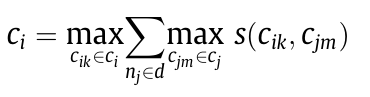

In [6]:
# from nltk.corpus import wordnet as wn

# # The paper restricts WSD to the top 3 senses of each noun.
# # Reason: WordNet lists senses in descending order of frequency,
# # so the first 3 cover the most common usages. Using all senses adds computation without really any meaningfulchanging results.
# MAX_SENSES = 3


# # -----------------------------------------------------------------------------
# def get_top_senses(word, max_senses=MAX_SENSES):
#     # Input  : word string      e.g. "bank"
#     # wn.synsets(word, pos=wn.NOUN) returns all noun senses, most frequent first
#     synsets = wn.synsets(word, pos=wn.NOUN)
#     return synsets[:max_senses]   # keep only the top N


# # -----------------------------------------------------------------------------
# def wu_palmer_similarity(synset_a, synset_b):
#     # computed between two synsets
#     # returns a float in [0, 1], or 0 if similarity cannot be computed

#     # measures how similar two concepts are based on their positions in the WordNet hierarchy and their lowest common ancestor.
#     # 1 means identical; 0 means completely unrelated.

#     score = synset_a.wup_similarity(synset_b)
#     # no path exists between synsets ? return NONE
#     return score if score is not None else 0.0


# # -----------------------------------------------------------------------------
# def disambiguate_word(target_word, context_words):
#     # Choose the best WordNet sense for target_word given a list of other nouns in the same document

#     target_senses = get_top_senses(target_word)

#     if not target_senses:
#         return None

#     if len(target_senses) == 1:
#         return target_senses[0]

#     best_sense = None
#     best_score = -1.0

#     for candidate_sense in target_senses:
#         total_score = 0.0

#         for context_word in context_words:
#             if context_word == target_word:
#                 continue   # skip comparing a word to itself

#             # Get the top senses of this context word
#             context_senses = get_top_senses(context_word)
#             if not context_senses:
#                 continue   # skip words not in WordNet

#             # Find the maximum similarity between the candidate sense
#             # and any sense of the context word (inner MAX in Formula 1)
#             max_sim = max(
#                 wu_palmer_similarity(candidate_sense, ctx_sense)
#                 for ctx_sense in context_senses
#             )
#             total_score += max_sim   # (outer SUM in Formula 1)

#         # Track the candidate sense with the highest total score
#         if total_score > best_score:
#             best_score = total_score
#             best_sense = candidate_sense

#     return best_sense


# # -----------------------------------------------------------------------------
# def disambiguate_document(noun_pairs):
    
#     # Run WSD on every noun in a single document.

#     # Input  : list of (stem, word) tuples
#     # Output : list of (stem, synset) tuples 
    
#     all_words = [word for (stem, word) in noun_pairs]

#     result = []
#     for (stem, word) in noun_pairs:
#         # all other words in the document serve as context
#         context = [w for w in all_words if w != word]
#         best_sense = disambiguate_word(word, context)
#         result.append((stem, best_sense))

#     return result


# # -----------------------------------------------------------------------------
# def disambiguate_corpus(noun_docs):
    
#     # Apply to every document in the corpus.
#     # Output : list of (stem, synset) lists (one per document)
    
#     wsd_docs = []
#     total = len(noun_docs)

#     for i, noun_pairs in enumerate(noun_docs):
#         if (i + 1) % 50 == 0 or (i + 1) == total:
#             print(f"  WSD: document {i+1}/{total}...")
#         wsd_docs.append(disambiguate_document(noun_pairs))

#     return wsd_docs



# print("Starting Word Sense Disambiguation...\n")
# wsd_docs = disambiguate_corpus(noun_docs)
# print("\nWSD complete.")

# # Count how many nouns were successfully mapped to a WordNet synset
# total_nouns    = sum(len(doc) for doc in wsd_docs)
# matched_nouns  = sum(
#     1 for doc in wsd_docs
#     for (stem, syn) in doc
#     if syn is not None
# )
# print(f"\nTotal noun tokens     : {total_nouns}")
# print(f"Matched to WordNet    : {matched_nouns}")
# print(f"WordNet coverage      : {100 * matched_nouns / total_nouns:.1f}%")

# # Show example for first document
# print(f"\nExample — WSD output for first document (first 5 pairs):")
# for stem, syn in wsd_docs[0][:5]:
#     if syn:
#         print(f"  stem='{stem}'  →  synset='{syn.name()}'  "
#               f"definition: '{syn.definition()[:60]}...'")
#     else:
#         print(f"  stem='{stem}'  →  NOT FOUND in WordNet")


In [10]:
import os
import pickle

from nltk.corpus import wordnet as wn

try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False

MAX_SENSES       = 3               # top N senses per word
WSD_CACHE_FILE   = 'wsd_docs.pkl'  # checkpoint filename

# These dictionaries persist for the entire notebook session.
# Once a value is computed it is never recomputed!! saves us computation
_synset_cache     = {}
# Maps  word (str)  →  list of up to MAX_SENSES Synset objects
# e.g.  "bank"  →  [Synset('bank.n.01'), Synset('bank.n.02'), ...]

_similarity_cache = {}
# Maps  frozenset({name_a, name_b})  →  float similarity score
# Using frozenset means (A,B) and (B,A) share one cache entry.
# e.g.  frozenset({'bank.n.01','river.n.01'})  →  0.421


# -----------------------------------------------------------------------------
def get_top_senses(word):
    
    # Result is cached so WordNet is only queried once per unique word
    # Input  : word string        e.g. "bank"
    # Output : list of Synsets    e.g. [Synset('bank.n.01'), ...]
    
    if word not in _synset_cache:
        synsets = wn.synsets(word, pos=wn.NOUN)
        _synset_cache[word] = synsets[:MAX_SENSES]
    return _synset_cache[word]


# -----------------------------------------------------------------------------
def wu_palmer_similarity(synset_a, synset_b):
    
    # Compute Wu-Palmer similarity with result caching.
    # similarity(A, B) and similarity(B, A) share the same entry.
    # Input  : two Synset objects
    # Output : float in [0.0, 1.0]
    
    key = frozenset([synset_a.name(), synset_b.name()])

    if key not in _similarity_cache:
        score = synset_a.wup_similarity(synset_b)
        _similarity_cache[key] = score if score is not None else 0.0

    return _similarity_cache[key]


# -----------------------------------------------------------------------------
def disambiguate_word(target_word, context_words_deduped):
    
    # Implements Formula (1) from the paper:
    #     best_sense = argmax_{s in senses(target)}
    #                      SUM_{w in context}
    #                          MAX_{t in senses(w)} similarity(s, t)
    # Optimisations applied:
    #   - Synset lookups cached via get_top_senses()
    #   - Similarity scores cached via wu_palmer_similarity()
    #   - Early exit when only one candidate sense exists
    #   - Context words are pre-deduplicated by the caller
    
    target_senses = get_top_senses(target_word)

    if not target_senses:
        return None                    # word not in WordNet

    if len(target_senses) == 1:
        return target_senses[0]        # no choice to make — skip computation

    best_sense = None
    best_score = -1.0

    for candidate in target_senses:
        total_score = 0.0

        for ctx_word in context_words_deduped:
            ctx_senses = get_top_senses(ctx_word)
            if not ctx_senses:
                continue

            # Inner MAX: best match between candidate and any sense of ctx_word
            max_sim = max(
                wu_palmer_similarity(candidate, ctx_sense)
                for ctx_sense in ctx_senses
            )
            total_score += max_sim     # outer SUM

        if total_score > best_score:
            best_score = total_score
            best_sense = candidate

    return best_sense


# -----------------------------------------------------------------------------
def disambiguate_document(noun_pairs):
    
    # Run WSD on all nouns in a single document
    # Optimisation: the context list is deduplicated once per document
    # rather than rebuilt inside every disambiguate_word call
    
    # Build a deduplicated list of all real words in this document
    #  dict.fromkeys preserves order while removing duplicates
    all_words_deduped = list(dict.fromkeys(
        word for (_, word) in noun_pairs
    ))

    result = []
    for (stem, word) in noun_pairs:
        # Context = every other unique word in the document
        context = [w for w in all_words_deduped if w != word]
        best_sense = disambiguate_word(word, context)
        result.append((stem, best_sense))

    return result


# -----------------------------------------------------------------------------
def disambiguate_corpus(noun_docs):
    
    # Input  : list of noun-pair lists
    # Output : list of (stem, synset_or_None) lists
    
    wsd_results = []
    total = len(noun_docs)

    iterator = (
        tqdm(noun_docs, desc="WSD Progress", unit="doc")
        if TQDM_AVAILABLE
        else noun_docs
    )

    for i, noun_pairs in enumerate(iterator):
        # Plain counter fallback when tqdm is unavailable
        if not TQDM_AVAILABLE and ((i + 1) % 50 == 0 or (i + 1) == total):
            print(f"  WSD: document {i+1}/{total}  "
                  f"| synset cache: {len(_synset_cache)} words  "
                  f"| sim cache: {len(_similarity_cache)} pairs")

        wsd_results.append(disambiguate_document(noun_pairs))

    return wsd_results


if os.path.exists(WSD_CACHE_FILE):
    print("Loading cached WSD results...")
    with open(WSD_CACHE_FILE, 'rb') as f:
        wsd_docs_names = pickle.load(f)
    # Restore synset names → Synset objects
    wsd_docs = [
        [(stem, wn.synset(name) if name is not None else None)
         for (stem, name) in doc]
        for doc in wsd_docs_names
    ]
    print("WSD complete.")

else:
    print("Running WSD...")
    print("(First run takes several minutes — subsequent runs load instantly)\n")
    wsd_docs = disambiguate_corpus(noun_docs)

    # Convert Synset objects → name strings before pickling
    wsd_docs_names = [
        [(stem, syn.name() if syn is not None else None)
         for (stem, syn) in doc]
        for doc in wsd_docs
    ]

    print("\nSaving WSD results...")
    with open(WSD_CACHE_FILE, 'wb') as f:
        pickle.dump(wsd_docs_names, f)
    print("WSD complete.")

total_nouns   = sum(len(doc) for doc in wsd_docs)
matched_nouns = sum(
    1 for doc in wsd_docs
    for (_, syn) in doc
    if syn is not None
)

print(f"\nTotal noun tokens  : {total_nouns}")
print(f"Matched to WordNet : {matched_nouns}")
print(f"WordNet coverage   : {100 * matched_nouns / total_nouns:.1f}%")
print(f"Synset cache size  : {len(_synset_cache)} unique words")
print(f"Sim cache size     : {len(_similarity_cache)} unique pairs")

print(f"\nExample — WSD output for first document (first 5 pairs):")
for stem, syn in wsd_docs[0][:5]:
    if syn:
        print(f"  stem='{stem:<12}'  synset='{syn.name():<22}' "
              f" def: '{syn.definition()[:55]}...'")
    else:
        print(f"  stem='{stem:<12}'  NOT FOUND in WordNet")

Loading cached WSD results...
WSD complete.

Total noun tokens  : 23216
Matched to WordNet : 18517
WordNet coverage   : 79.8%
Synset cache size  : 0 unique words
Sim cache size     : 0 unique pairs

Example — WSD output for first document (first 5 pairs):
  stem='year        '  synset='year.n.01             '  def: 'a period of time containing 365 (or 366) days...'
  stem='year        '  synset='year.n.01             '  def: 'a period of time containing 365 (or 366) days...'
  stem='drink       '  synset='beverage.n.01         '  def: 'any liquid suitable for drinking...'
  stem='tri         '  NOT FOUND in WordNet
  stem='line        '  synset='line.n.01             '  def: 'a formation of people or things one beside another...'


# SECTION 6: LEXICAL CHAIN FUNCTIONS

In [12]:
# ============================================================
# SECTION 6: LEXICAL CHAIN FUNCTIONS  (final version)
# ============================================================

WEIGHT_SYNONYM  = 0.8
WEIGHT_HYPERNYM = 0.5
WEIGHT_MERONYM  = 0.3

# Depth 3 gives a good balance:
#   depth 1 → all singletons (too strict)
#   depth 2 → 81% singletons (still too strict)
#   depth 3 → captures domain-level groupings (space, medicine, sports etc.)
#   depth 4+ → over-merges unrelated concepts via distant WordNet root
RELATION_DEPTH = 3

# Wu-Palmer similarity threshold for LCS fallback.
# Two synsets that are not directly related by hypernym/meronym
# but have WP similarity above this threshold are still considered
# related for chaining purposes.
# 0.5 is conservative enough to avoid false merges.
WP_FALLBACK_THRESHOLD = 0.5


# -----------------------------------------------------------------------------
def get_ancestors(synset, depth):
    """
    Collect all hypernym synsets reachable within `depth` hops upward.
    Identical to previous version.
    """
    visited = set()
    frontier = [synset]
    for _ in range(depth):
        next_frontier = []
        for s in frontier:
            for h in s.hypernyms():
                if h not in visited:
                    visited.add(h)
                    next_frontier.append(h)
        frontier = next_frontier
    return visited


# -----------------------------------------------------------------------------
def get_meronyms(synset, depth):
    """
    Collect all meronym synsets reachable within `depth` hops.
    Identical to previous version.
    """
    def direct_meronyms(s):
        return (s.part_meronyms() +
                s.substance_meronyms() +
                s.member_meronyms())

    visited = set()
    frontier = [synset]
    for _ in range(depth):
        next_frontier = []
        for s in frontier:
            for m in direct_meronyms(s):
                if m not in visited:
                    visited.add(m)
                    next_frontier.append(m)
        frontier = next_frontier
    return visited


# -----------------------------------------------------------------------------
def get_relation(synset_a, synset_b):
    """
    Determine whether two synsets share a semantic relation and
    return the corresponding weight. Checks in priority order:

      1. Identity   — same synset
      2. Synonym    — shared lemma name
      3. Hypernym   — ancestor or shared ancestor within RELATION_DEPTH hops
      4. Meronym    — part-of relation within RELATION_DEPTH hops
      5. WP fallback— Wu-Palmer similarity above WP_FALLBACK_THRESHOLD
                      catches domain-related concepts that sit too far
                      apart for structural checks alone

    Input  : two Synset objects
    Output : float weight if related, None otherwise
    """

    # identity
    if synset_a == synset_b:
        return WEIGHT_SYNONYM

    # synonym
    lemmas_a = set(l.name() for l in synset_a.lemmas())
    lemmas_b = set(l.name() for l in synset_b.lemmas())
    if lemmas_a & lemmas_b:
        return WEIGHT_SYNONYM

    # Hypernym / shared ancestor within RELATION_DEPTH 
    ancestors_a = get_ancestors(synset_a, RELATION_DEPTH)
    ancestors_b = get_ancestors(synset_b, RELATION_DEPTH)

    if synset_b in ancestors_a or synset_a in ancestors_b:
        return WEIGHT_HYPERNYM

    if ancestors_a & ancestors_b:
        return WEIGHT_HYPERNYM

    # Meronym within RELATION_DEPTH 
    meronyms_a = get_meronyms(synset_a, RELATION_DEPTH)
    meronyms_b = get_meronyms(synset_b, RELATION_DEPTH)

    if synset_b in meronyms_a or synset_a in meronyms_b:
        return WEIGHT_MERONYM

    if meronyms_a & meronyms_b:
        return WEIGHT_MERONYM

    # Wu-Palmer similarity fallback 
    # adds no extra WordNet traversal cost for pairs already seen in WSD.
    wp_score = wu_palmer_similarity(synset_a, synset_b)
    if wp_score >= WP_FALLBACK_THRESHOLD:
        return WEIGHT_HYPERNYM   # treat as hypernym-strength relation

    return None


# -----------------------------------------------------------------------------
def build_lexical_chains(wsd_pairs):
    valid_pairs = [(stem, syn) for (stem, syn) in wsd_pairs
                   if syn is not None]
    if not valid_pairs:
        return []

    # Concept weights (term frequency, summed for synonyms)
    synset_weight = {}
    synset_stem   = {}
    for stem, syn in valid_pairs:
        name = syn.name()
        synset_weight[name] = synset_weight.get(name, 0) + 1
        if name not in synset_stem:
            synset_stem[name] = stem

    # Deduplicated unique concepts
    seen = {}
    for _, syn in valid_pairs:
        seen[syn.name()] = syn
    unique_pairs = [(synset_stem[name], syn) for name, syn in seen.items()]

    n = len(unique_pairs)

    # Union-Find
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[rx] = ry

    for i in range(n):
        for j in range(i + 1, n):
            if find(i) != find(j):
                _, syn_i = unique_pairs[i]
                _, syn_j = unique_pairs[j]
                if get_relation(syn_i, syn_j) is not None:
                    union(i, j)

    # Group by chain root
    chains_dict = {}
    for i, (stem, syn) in enumerate(unique_pairs):
        root = find(i)
        if root not in chains_dict:
            chains_dict[root] = []
        chains_dict[root].append((stem, syn, synset_weight[syn.name()]))

    return list(chains_dict.values())


# -----------------------------------------------------------------------------
def build_chains_for_corpus(wsd_docs):

    # Apply build_lexical_chains to every document in the corpus.
    chain_docs = []
    total = len(wsd_docs)
    for i, wsd_pairs in enumerate(wsd_docs):
        if (i + 1) % 100 == 0 or (i + 1) == total:
            print(f"  Building chains: document {i+1}/{total}...")
        chain_docs.append(build_lexical_chains(wsd_pairs))
    return chain_docs


print("Building lexical chains (depth=3 + WP fallback)...\n")
chain_docs = build_chains_for_corpus(wsd_docs)
print("\nLexical chain construction complete.")

total_chains   = sum(len(chains) for chains in chain_docs)
total_concepts = sum(len(c) for chains in chain_docs for c in chains)
chain_lengths  = [len(c) for chains in chain_docs for c in chains]

avg_chains_per_doc = total_chains / len(chain_docs)
avg_chain_length   = total_concepts / total_chains if total_chains else 0
singleton_count    = sum(1 for l in chain_lengths if l == 1)

print(f"\nTotal documents      : {len(chain_docs)}")
print(f"Total chains         : {total_chains}")
print(f"Avg chains / doc     : {avg_chains_per_doc:.1f}")
print(f"Total concepts       : {total_concepts}")
print(f"Avg concepts / chain : {avg_chain_length:.1f}")
print(f"Longest chain        : {max(chain_lengths)} concepts")
print(f"Single-node chains   : {singleton_count} "
      f"({100 * singleton_count / total_chains:.1f}%)")

# largest chains for first document
print(f"\nExample — top 3 largest chains for first document:")
sorted_chains = sorted(chain_docs[0], key=lambda c: len(c), reverse=True)
for idx, chain in enumerate(sorted_chains[:3]):
    print(f"\n  Chain {idx+1} ({len(chain)} concept(s)):")
    for stem, syn, weight in chain[:5]:   # show max 5 concepts per chain
        print(f"    stem='{stem:<12}'  synset='{syn.name():<25}'"
              f"  w={weight}  '{syn.definition()[:45]}...'")
    if len(chain) > 5:
        print(f"    ... and {len(chain)-5} more concepts")

Building lexical chains (depth=3 + WP fallback)...

  Building chains: document 100/600...
  Building chains: document 200/600...
  Building chains: document 300/600...
  Building chains: document 400/600...
  Building chains: document 500/600...
  Building chains: document 600/600...

Lexical chain construction complete.

Total documents      : 600
Total chains         : 2708
Avg chains / doc     : 4.5
Total concepts       : 12791
Avg concepts / chain : 4.7
Longest chain        : 469 concepts
Single-node chains   : 1379 (50.9%)

Example — top 3 largest chains for first document:

  Chain 1 (10 concept(s)):
    stem='drink       '  synset='beverage.n.01            '  w=1  'any liquid suitable for drinking...'
    stem='size        '  synset='size.n.03                '  w=1  'any glutinous material used to fill pores in ...'
    stem='can         '  synset='can.n.01                 '  w=1  'airtight sealed metal container for food or d...'
    stem='scrap       '  synset='garbage.n.01  

In [13]:
# check to make sure chains are right
def print_document_chains(doc_id,
                          max_chains=10,
                          max_concepts_per_chain=20):
    
    if doc_id >= len(chain_docs):
        print(f"Document {doc_id} does not exist.")
        return

    chains = sorted(
        chain_docs[doc_id],
        key=lambda c: len(c),
        reverse=True
    )

    print("=" * 80)
    print(f"DOCUMENT {doc_id}")
    print(f"Total chains: {len(chains)}")
    print("=" * 80)

    for chain_no, chain in enumerate(chains[:max_chains], start=1):

        print(f"\nCHAIN {chain_no}")
        print(f"Size: {len(chain)} concepts")
        print("-" * 60)

        for stem, syn, weight in chain[:max_concepts_per_chain]:
            print(
                f"{stem:<15}"
                f"{syn.name():<30}"
                f"freq={weight:<3}"
                f"{syn.definition()}"
            )

        if len(chain) > max_concepts_per_chain:
            print(f"... {len(chain)-max_concepts_per_chain} more concepts")



docs_to_check = [0, 1, 2, 3, 4]

for doc_id in docs_to_check:
    print_document_chains(
        doc_id,
        max_chains=5,
        max_concepts_per_chain=15
    )
    print("\n\n")

DOCUMENT 0
Total chains: 8

CHAIN 1
Size: 10 concepts
------------------------------------------------------------
drink          beverage.n.01                 freq=1  any liquid suitable for drinking
size           size.n.03                     freq=1  any glutinous material used to fill pores in surfaces or to stiffen fabrics
can            can.n.01                      freq=1  airtight sealed metal container for food or drink or paint etc.
scrap          garbage.n.01                  freq=1  food that is discarded (as from a kitchen)
box            box.n.01                      freq=1  a (usually rectangular) container; may have a lid
bullet         bullet.n.01                   freq=1  a projectile that is fired from a gun
shell          shell.n.02                    freq=2  the material that forms the hard outer covering of many animals
board          board.n.03                    freq=1  a flat piece of material designed for a special purpose
inhal          inhalant.n.02         

* Section 7: Core Semantic Feature Extraction*

keeping only the important chains, dropping weak/single-word ones

In [14]:

MIN_CHAIN_LENGTH = 2    # ignore chains with only 1 word
TOP_CHAINS_RATIO = 0.5  # keep top 50% chains per document

def score_chain(chain):
    # longer chains with frequent words = more important
    if not chain:
        return 0.0
    length = len(chain)
    avg_freq = sum(w for (_, _, w) in chain) / length
    return length * avg_freq


def extract_core_features(chains):
    # step 1: drop single-node chains
    filtered = [c for c in chains if len(c) >= MIN_CHAIN_LENGTH]
    
    if not filtered:
        filtered = chains  # fallback if document is very short
    
    # step 2: score and sort chains
    scored = sorted(
        [(score_chain(c), c) for c in filtered],
        key=lambda x: x[0],
        reverse=True
    )
    
    # step 3: keep top 50%
    keep = max(1, int(len(scored) * TOP_CHAINS_RATIO))
    top_chains = [c for (_, c) in scored[:keep]]
    
    # step 4: extract stems (these become our features for TF-IDF)
    core_stems = []
    for chain in top_chains:
        for (stem, _, weight) in chain:
            core_stems.extend([stem] * weight)
    
    return core_stems


def extract_core_features_corpus(chain_docs):
    core_docs = []
    total = len(chain_docs)
    for i, chains in enumerate(chain_docs):
        if (i + 1) % 100 == 0 or (i + 1) == total:
            print(f"  document {i+1}/{total} done...")
        core_docs.append(extract_core_features(chains))
    return core_docs


print("Extracting core features...\n")
core_docs = extract_core_features_corpus(chain_docs)
print("\nDone.")

# quick check
total_before = sum(len(d) for d in preprocessed_docs)
total_after  = sum(len(d) for d in core_docs)
print(f"\nBefore : {total_before} features")
print(f"After  : {total_after} features")
print(f"Reduced: {100*(1 - total_after/total_before):.1f}%")
print(f"\nFirst doc core features (first 15): {core_docs[0][:15]}")

Extracting core features...

  document 100/600 done...
  document 200/600 done...
  document 300/600 done...
  document 400/600 done...
  document 500/600 done...
  document 600/600 done...

Done.

Before : 43240 features
After  : 14224 features
Reduced: 67.1%

First doc core features (first 15): ['drink', 'size', 'can', 'scrap', 'box', 'bullet', 'shell', 'shell', 'board', 'inhal', 'primer']


# Section 8: TF-IDF Vectorization
# converting document word lists into numeric vectors


In [16]:

from sklearn.feature_extraction.text import TfidfVectorizer

def stems_to_string(stem_list):
    # TfidfVectorizer needs a string not a list
    return ' '.join(stem_list)

# convert all three systems' docs to strings
baseline_strings = [stems_to_string(doc) for doc in preprocessed_docs]
dc_strings       = [stems_to_string([stem for (stem, _) in doc]) for doc in noun_docs]
dcs_strings      = [stems_to_string(doc) for doc in core_docs]

# TF-IDF vectorizer
# max_features=5000 keeps vocabulary manageable
vectorizer_baseline = TfidfVectorizer(max_features=5000)
vectorizer_dc       = TfidfVectorizer(max_features=5000)
vectorizer_dcs      = TfidfVectorizer(max_features=5000)

# fit and transform each system
X_baseline = vectorizer_baseline.fit_transform(baseline_strings)
X_dc       = vectorizer_dc.fit_transform(dc_strings)
X_dcs      = vectorizer_dcs.fit_transform(dcs_strings)

print("TF-IDF vectorization complete.")
print(f"\nBaseline matrix : {X_baseline.shape}")
print(f"DC matrix       : {X_dc.shape}")
print(f"DCS matrix      : {X_dcs.shape}")

TF-IDF vectorization complete.

Baseline matrix : (600, 5000)
DC matrix       : (600, 5000)
DCS matrix      : (600, 2648)


# Section 9: Clustering Functions
# using K-Means to group documents into clusters

In [18]:

from sklearn.cluster import KMeans

def run_kmeans(X, n_clusters, random_state=42):
    # n_init=10 means algorithm runs 10 times with different starting points
    # best result out of 10 runs is kept to avoid bad clustering
    kmeans = KMeans(
        n_clusters=n_clusters,
        n_init=10,
        random_state=random_state
    )
    kmeans.fit(X)
    return kmeans.labels_  # returns which cluster each document belongs to

print("Running K-Means clustering...\n")

# run clustering for all three systems separately
labels_baseline = run_kmeans(X_baseline, NUM_CLUSTERS)
print(f"Baseline done. Clusters found: {len(set(labels_baseline))}")

labels_dc = run_kmeans(X_dc, NUM_CLUSTERS)
print(f"DC done.       Clusters found: {len(set(labels_dc))}")

labels_dcs = run_kmeans(X_dcs, NUM_CLUSTERS)
print(f"DCS done.      Clusters found: {len(set(labels_dcs))}")

print("\nClustering complete.")

Running K-Means clustering...

Baseline done. Clusters found: 6
DC done.       Clusters found: 6
DCS done.      Clusters found: 6

Clustering complete.



 Section 10: Evaluation

 measuring how well our clustering matches the true categories


In [19]:

import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

def compute_purity(true_labels, predicted_labels):
    # purity measures what percentage of documents are correctly clustered
    # for each cluster, find the most common true label in it
    # purity = total correctly assigned / total documents
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)
    
    total = len(true_labels)
    correct = 0
    
    for cluster_id in set(predicted_labels):
        # get all true labels for documents in this cluster
        mask = predicted_labels == cluster_id
        cluster_true_labels = true_labels[mask]
        # most common true label in this cluster
        most_common = np.bincount(cluster_true_labels).argmax()
        correct += np.sum(cluster_true_labels == most_common)
    
    return correct / total


def compute_f1(true_labels, predicted_labels, n_clusters):
    # use hungarian algorithm to find best mapping between
    # predicted cluster ids and true label ids
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)
    
    # build confusion matrix
    confusion = np.zeros((n_clusters, n_clusters), dtype=int)
    for t, p in zip(true_labels, predicted_labels):
        confusion[t][p] += 1
    
    # hungarian algorithm finds best cluster-to-label assignment
    row_ind, col_ind = linear_sum_assignment(-confusion)
    
    # remap predicted labels using best assignment
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    remapped = np.array([mapping.get(p, p) for p in predicted_labels])
    
    # macro F1 over all classes
    from sklearn.metrics import f1_score
    return f1_score(true_labels, remapped, average='macro')


def compute_entropy(true_labels, predicted_labels):
    # lower entropy = better clustering
    # each cluster should ideally contain only one category
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)
    
    total = len(true_labels)
    entropy = 0.0
    
    for cluster_id in set(predicted_labels):
        mask = predicted_labels == cluster_id
        cluster_true = true_labels[mask]
        cluster_size = len(cluster_true)
        
        # entropy for this cluster
        cluster_entropy = 0.0
        for label in set(cluster_true):
            prob = np.sum(cluster_true == label) / cluster_size
            if prob > 0:
                cluster_entropy -= prob * np.log2(prob)
        
        # weighted by cluster size
        entropy += (cluster_size / total) * cluster_entropy
    
    return entropy


def evaluate(true_labels, predicted_labels, n_clusters, system_name):
    purity  = compute_purity(true_labels, predicted_labels)
    f1      = compute_f1(true_labels, predicted_labels, n_clusters)
    entropy = compute_entropy(true_labels, predicted_labels)
    nmi     = normalized_mutual_info_score(true_labels, predicted_labels)
    ari     = adjusted_rand_score(true_labels, predicted_labels)
    
    print(f"\n--- {system_name} ---")
    print(f"Purity  : {purity:.4f}  (higher is better)")
    print(f"F1      : {f1:.4f}  (higher is better)")
    print(f"Entropy : {entropy:.4f}  (lower is better)")
    print(f"NMI     : {nmi:.4f}  (higher is better)")
    print(f"ARI     : {ari:.4f}  (higher is better)")
    
    return {
        'system': system_name,
        'purity': purity,
        'f1': f1,
        'entropy': entropy,
        'nmi': nmi,
        'ari': ari
    }


print("Evaluating all three systems...\n")
true_labels = np.array(true_labels)

results_baseline = evaluate(true_labels, labels_baseline, NUM_CLUSTERS, "Baseline")
results_dc       = evaluate(true_labels, labels_dc,       NUM_CLUSTERS, "DC")
results_dcs      = evaluate(true_labels, labels_dcs,      NUM_CLUSTERS, "DCS")

print("\nEvaluation complete.")

Evaluating all three systems...


--- Baseline ---
Purity  : 0.5167  (higher is better)
F1      : 0.5361  (higher is better)
Entropy : 1.8278  (lower is better)
NMI     : 0.3047  (higher is better)
ARI     : 0.1923  (higher is better)

--- DC ---
Purity  : 0.4617  (higher is better)
F1      : 0.4861  (higher is better)
Entropy : 1.9186  (lower is better)
NMI     : 0.2710  (higher is better)
ARI     : 0.1452  (higher is better)

--- DCS ---
Purity  : 0.3417  (higher is better)
F1      : 0.3515  (higher is better)
Entropy : 2.2258  (lower is better)
NMI     : 0.1630  (higher is better)
ARI     : 0.0297  (higher is better)

Evaluation complete.


# Section 11, 12, 13: Baseline, DC and DCS Experiments
# running all three systems and storing results for comparison

In [21]:
print("=" * 60)
print("EXPERIMENT 1: BASELINE")
print("=" * 60)
print("Pipeline: Raw text → TF-IDF → K-Means")
print("No WSD, no lexical chains, just raw stems")
print()
results_baseline = evaluate(true_labels, labels_baseline, NUM_CLUSTERS, "Baseline")

print()
print("=" * 60)
print("EXPERIMENT 2: DC (Disambiguated Concepts)")
print("=" * 60)
print("Pipeline: Nouns → WSD → TF-IDF → K-Means")
print("WSD applied but no lexical chains")
print()
results_dc = evaluate(true_labels, labels_dc, NUM_CLUSTERS, "DC")

print()
print("=" * 60)
print("EXPERIMENT 3: DCS (Disambiguated Core Semantics)")
print("=" * 60)
print("Pipeline: Nouns → WSD → Lexical Chains → Core Features → TF-IDF → K-Means")
print("Full paper pipeline")
print()
results_dcs = evaluate(true_labels, labels_dcs, NUM_CLUSTERS, "DCS")

print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"{'System':<12} {'Purity':>8} {'F1':>8} {'Entropy':>10} {'NMI':>8} {'ARI':>8}")
print("-" * 60)
for r in [results_baseline, results_dc, results_dcs]:
    print(f"{r['system']:<12} {r['purity']:>8.4f} {r['f1']:>8.4f} {r['entropy']:>10.4f} {r['nmi']:>8.4f} {r['ari']:>8.4f}")

EXPERIMENT 1: BASELINE
Pipeline: Raw text → TF-IDF → K-Means
No WSD, no lexical chains, just raw stems


--- Baseline ---
Purity  : 0.5167  (higher is better)
F1      : 0.5361  (higher is better)
Entropy : 1.8278  (lower is better)
NMI     : 0.3047  (higher is better)
ARI     : 0.1923  (higher is better)

EXPERIMENT 2: DC (Disambiguated Concepts)
Pipeline: Nouns → WSD → TF-IDF → K-Means
WSD applied but no lexical chains


--- DC ---
Purity  : 0.4617  (higher is better)
F1      : 0.4861  (higher is better)
Entropy : 1.9186  (lower is better)
NMI     : 0.2710  (higher is better)
ARI     : 0.1452  (higher is better)

EXPERIMENT 3: DCS (Disambiguated Core Semantics)
Pipeline: Nouns → WSD → Lexical Chains → Core Features → TF-IDF → K-Means
Full paper pipeline


--- DCS ---
Purity  : 0.3417  (higher is better)
F1      : 0.3515  (higher is better)
Entropy : 2.2258  (lower is better)
NMI     : 0.1630  (higher is better)
ARI     : 0.0297  (higher is better)

SUMMARY
System         Purity       